# 04 - Đánh giá Baseline Model

**Phase 1 | OCR bán giám sát cho chữ viết tay tiếng Việt**

## Mục tiêu

Notebook này đánh giá toàn diện mô hình Baseline trên tập validation.


In [15]:
# ============================================================
# CẤU HÌNH
# ============================================================

CONFIG = {
    # Đường dẫn
    "model_path": "../models/baseline/best_model.pth",
    "val_line_path": "../data/processed/val_line.txt",
    "test_line_path": "../data/processed/test.txt",
    "eval_split": "test",  # chọn: "val" hoặc "test"
    "data_root": "../Dataset/data/",
    "output_dir": "../models/baseline/",

    # Mô hình (phải khớp training config)
    "backbone": "vgg19_bn",
    "image_height": 32,
    "image_max_width": 690,
    "image_min_width": 32,
    "grayscale": True,
    "device": "cuda:0",

    # Evaluation
    "length_buckets": {"short": (0, 30), "medium": (30, 80), "long": (80, 999)},
    "num_worst": 20,
}

assert CONFIG["eval_split"] in {"val", "test"}, "eval_split must be 'val' or 'test'"

print("Đã nạp CONFIG.")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Đã nạp CONFIG.
  model_path: ../models/baseline/best_model.pth
  val_line_path: ../data/processed/val_line.txt
  test_line_path: ../data/processed/test.txt
  eval_split: test
  data_root: ../Dataset/data/
  output_dir: ../models/baseline/
  backbone: vgg19_bn
  image_height: 32
  image_max_width: 690
  image_min_width: 32
  grayscale: True
  device: cuda:0
  length_buckets: {'short': (0, 30), 'medium': (30, 80), 'long': (80, 999)}
  num_worst: 20


## Điều chỉnh: Loại bỏ xử lý từ vựng thủ công

**Thay đổi:** Đã loại bỏ toàn bộ phần nạp từ vựng thủ công, ghi đè `config["vocab"]`, và các tham chiếu `vocab_path`.

**Lý do:**
- `Cfg.load_config_from_name()` của VietOCR đã có sẵn bộ ký tự tiếng Việt tương thích pretrained weights.
- Ghi đè `config["vocab"]` thủ công có thể gây lỗi lệch kích thước embedding decoder khi nạp trọng số.
- Cách này đảm bảo Predictor nạp weights ổn định, không lỗi tensor shape mismatch.

**Ý nghĩa:**
- Từ vựng do VietOCR quản lý nội bộ.
- Không cần `vocab.txt`.
- Không gán tay `config["vocab"]`.

In [16]:
# ============================================================
# IMPORTS
# ============================================================

import os
import json
import unicodedata
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.notebook import tqdm

import torch
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg

import jiwer

# Thiết lập style biểu đồ
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# GPU fallback
if CONFIG["device"].startswith("cuda") and not torch.cuda.is_available():
    print("[WARN] CUDA not available. Falling back to CPU.")
    CONFIG["device"] = "cpu"
else:
    print(f"Đang dùng device: {CONFIG['device']}")

print("Đã nạp tất cả Imports thành công.")

Đang dùng device: cuda:0
Đã nạp tất cả Imports thành công.


In [17]:
# ============================================================
# HÀM HỖ TRỢ
# ============================================================


def compute_cer(prediction: str, ground_truth: str) -> float:
    """Tính Character Error Rate giữa prediction và ground truth."""
    if len(ground_truth) == 0 and len(prediction) == 0:
        return 0.0
    if len(ground_truth) == 0:
        return 1.0
    return jiwer.cer(ground_truth, prediction)


def compute_wer(prediction: str, ground_truth: str) -> float:
    """Tính Word Error Rate giữa prediction và ground truth."""
    if len(ground_truth.strip()) == 0 and len(prediction.strip()) == 0:
        return 0.0
    if len(ground_truth.strip()) == 0:
        return 1.0
    return jiwer.wer(ground_truth, prediction)


def extract_source(image_path: str) -> str:
    """Tách source prefix từ tên ảnh."""
    basename = os.path.basename(image_path)
    if "__" in basename:
        return basename.split("__")[0]
    return "unknown"


def resolve_image_path(image_path: str, data_root: str) -> str:
    """Ghép đường dẫn ảnh an toàn, tránh lặp data/data."""
    rel_path = image_path
    if rel_path.startswith("data/"):
        rel_path = rel_path[len("data/"):]
    return os.path.join(data_root, rel_path)


def character_alignment(pred: str, gt: str) -> list:
    """Căn chỉnh ký tự bằng Levenshtein, trả về các cặp thay thế."""
    n = len(gt)
    m = len(pred)

    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if gt[i - 1] == pred[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = 1 + min(
                    dp[i - 1][j],
                    dp[i][j - 1],
                    dp[i - 1][j - 1],
                )

    substitutions = []
    i, j = n, m
    while i > 0 and j > 0:
        if gt[i - 1] == pred[j - 1]:
            i -= 1
            j -= 1
        elif dp[i][j] == dp[i - 1][j - 1] + 1:
            substitutions.append((gt[i - 1], pred[j - 1]))
            i -= 1
            j -= 1
        elif dp[i][j] == dp[i - 1][j] + 1:
            i -= 1
        else:
            j -= 1

    return substitutions


def build_confusion_pairs(all_alignments: list) -> list:
    """Đếm tần suất các cặp nhầm ký tự."""
    pair_counts = Counter()
    for alignment in all_alignments:
        for gt_char, pred_char in alignment:
            pair_counts[(gt_char, pred_char)] += 1

    sorted_pairs = [
        (gt_c, pred_c, count)
        for (gt_c, pred_c), count in pair_counts.most_common()
    ]
    return sorted_pairs


def visualize_worst(results_df: pd.DataFrame, n: int = 20) -> None:
    """Hiển thị n mẫu có CER cao nhất."""
    worst = results_df.nlargest(n, "cer").reset_index(drop=True)
    n_actual = len(worst)

    n_cols = 4
    n_rows = (n_actual + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    fig.suptitle(f"Top {n_actual} Worst Predictions (by CER)", fontsize=16, fontweight="bold")

    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes_flat = axes.flatten()

    for idx in range(n_actual):
        row = worst.iloc[idx]
        ax = axes_flat[idx]

        full_path = resolve_image_path(row["image_path"], CONFIG["data_root"])

        try:
            img = Image.open(full_path).convert("RGB")
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error:\n{e}",
                    ha="center", va="center", fontsize=8,
                    transform=ax.transAxes)

        gt_display = row["ground_truth"]
        pred_display = row["prediction"]
        if len(gt_display) > 50:
            gt_display = gt_display[:47] + "..."
        if len(pred_display) > 50:
            pred_display = pred_display[:47] + "..."

        title = (
            f"CER: {row['cer']:.3f}\n"
            f"GT:  {gt_display}\n"
            f"PR:  {pred_display}"
        )
        ax.set_title(title, fontsize=8, ha="left", loc="left", pad=4)
        ax.axis("off")

    for idx in range(n_actual, len(axes_flat)):
        axes_flat[idx].axis("off")

    plt.tight_layout()
    plt.show()


print("Helper functions defined:")
print("  - compute_cer(prediction, ground_truth)")
print("  - compute_wer(prediction, ground_truth)")
print("  - extract_source(image_path)")
print("  - resolve_image_path(image_path, data_root)")
print("  - character_alignment(pred, gt)")
print("  - build_confusion_pairs(all_alignments)")
print("  - visualize_worst(results_df, n)")

Helper functions defined:
  - compute_cer(prediction, ground_truth)
  - compute_wer(prediction, ground_truth)
  - extract_source(image_path)
  - resolve_image_path(image_path, data_root)
  - character_alignment(pred, gt)
  - build_confusion_pairs(all_alignments)
  - visualize_worst(results_df, n)


## 1. Tải model và dữ liệu đánh giá (val/test)


In [18]:
# --------------------------------------------------
# 1. Tải Model & dữ liệu đánh giá
# --------------------------------------------------

# --- 1a. Tải VietOCR config và override theo training ---
config = Cfg.load_config_from_name("vgg_seq2seq")

config["backbone"] = CONFIG["backbone"]
config["device"] = CONFIG["device"]
config["weights"] = CONFIG["model_path"]
config["cnn"]["pretrained"] = False
config["dataset"]["image_height"] = CONFIG["image_height"]
config["dataset"]["image_max_width"] = CONFIG["image_max_width"]
config["dataset"]["image_min_width"] = CONFIG["image_min_width"]

print(f"Model config:")
print(f"  Backbone: {config['backbone']}")
print(f"  Device: {config['device']}")
print(f"  Weights: {config['weights']}")
print(f"  image_height: {config['dataset']['image_height']}")
print(f"  image_max_width: {config['dataset']['image_max_width']}")

# --- 1b. Tạo Predictor ---
predictor = Predictor(config)
print("\nPredictor created successfully.")

# --- 1c. Parse eval file ---
eval_line_path = CONFIG["test_line_path"] if CONFIG["eval_split"] == "test" else CONFIG["val_line_path"]
eval_entries = []
with open(eval_line_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.rstrip("\n").rstrip("\r")
        if not line.strip():
            continue
        parts = line.split("\t", maxsplit=1)
        if len(parts) == 2:
            eval_entries.append((parts[0], parts[1]))
        else:
            eval_entries.append((parts[0], ""))

print(f"\nEval split: {CONFIG['eval_split']}")
print(f"Eval file : {eval_line_path}")
print(f"Kích thước tập đánh giá: {len(eval_entries):,} samples")
print(f"\nFirst 5 entries:")
for img, gt in eval_entries[:5]:
    print(f"  {img}  ->  {gt[:60]}{'...' if len(gt) > 60 else ''}")

Model config:
  Backbone: vgg19_bn
  Device: cuda:0
  Weights: ../models/baseline/best_model.pth
  image_height: 32
  image_max_width: 690

Predictor created successfully.

Eval split: test
Eval file : ../data/processed/test.txt
Kích thước tập đánh giá: 1,637 samples

First 5 entries:
  vn_handwritten_images__1575_samples.png  ->  Số 126 Phú Thuận, Thị trấn D-Ran, Huyện Đơn Dương, Lâm Đồng
  UIT_HWDB_line_flat__220_18.jpg  ->  công khai, hiện vẫn được dựng công khai cách trụ sở UBND xã ...
  UIT_HWDB_line_flat__30_36.jpg  ->  này người ta thường gọi bằng từ " xóc chéo ", thấy thương
  UIT_HWDB_line_flat__198_15.jpg  ->  Có tài nguyên sinh vật và khoáng sản phong phú, đa dạng, quý...
  UIT_HWDB_line_flat__32_19.jpg  ->  dùng cả kim tẩm độc châm vào mình gà. Dính phải những " độc ...


## 2. Chạy dự đoán trên toàn bộ tập đánh giá


In [19]:
# --------------------------------------------------
# 2. Chạy dự đoán trên full eval set
# --------------------------------------------------

results = []
errors = []

use_grayscale = CONFIG["grayscale"]

for img_path, gt in tqdm(eval_entries, desc=f"Predicting-{CONFIG['eval_split']}"):
    full_path = resolve_image_path(img_path, CONFIG["data_root"])

    try:
        img = Image.open(full_path)
        if use_grayscale:
            img = img.convert("L").convert("RGB")
        else:
            img = img.convert("RGB")

        prediction = predictor.predict(img)
        source = extract_source(img_path)

        results.append({
            "image_path": img_path,
            "ground_truth": gt,
            "prediction": prediction,
            "source": source,
        })
    except Exception as e:
        errors.append((img_path, str(e)))

df = pd.DataFrame(results)

print(f"\nPredictions completed on {CONFIG['eval_split']}: {len(df):,} successful, {len(errors)} errors.")
if errors:
    print(f"\nFirst 5 errors:")
    for path, err in errors[:5]:
        print(f"  {path}: {err}")

print(f"\n{'='*80}")
print(f"{'#':>3}  {'Ground Truth':<40} {'Prediction':<40}")
print(f"{'-'*80}")
for i, row in df.head(10).iterrows():
    gt_disp = row['ground_truth'][:38] + '...' if len(row['ground_truth']) > 38 else row['ground_truth']
    pr_disp = row['prediction'][:38] + '...' if len(row['prediction']) > 38 else row['prediction']
    print(f"{i:>3}  {gt_disp:<40} {pr_disp:<40}")

Predicting-test:   0%|          | 0/1637 [00:00<?, ?it/s]


Predictions completed on test: 1,637 successful, 0 errors.

  #  Ground Truth                             Prediction                              
--------------------------------------------------------------------------------
  0  Số 126 Phú Thuận, Thị trấn D-Ran, Huyệ... Số 126 Phú Thuận, Thị trấn D- aa, Huyệ...
  1  công khai, hiện vẫn được dựng công kha... công khai, hiện vẫn được dựng công kha...
  2  này người ta thường gọi bằng từ " xóc ... này người ta thường gọi bằng từ " xóc ...
  3  Có tài nguyên sinh vật và khoáng sản p... Có tài nguyên sinh vật và khoáng sản p...
  4  dùng cả kim tẩm độc châm vào mình gà. ... dùng cả kim tẩm độc châu vào mình gà. ...
  5  trong lĩnh vực đất đai và các công trì... trong lĩnh vực đất đai và các công trì...
  6  800 triệu đồng ủng hộ bệnh nhân nghèo.... 800 triệu đồng ứng hộ bệnh nhân nghèo....
  7  xác định ưu tiên về xây dựng năng lực ... xác định ưu tiên về xây dựng năng lực ...
  8  tranh chống tiêu cực ở công trình đườn... tranh chống 

## 3. CER & WER tổng thể


METRICS ĐÁNH GIÁ TỔNG THỂ


,Metric,Value
0,Macro CER,0.0443
1,Macro WER,0.1213
2,Full-Sequence Accuracy (%),31.70%
3,Exact Matches,519
4,Total Samples,"1,637"


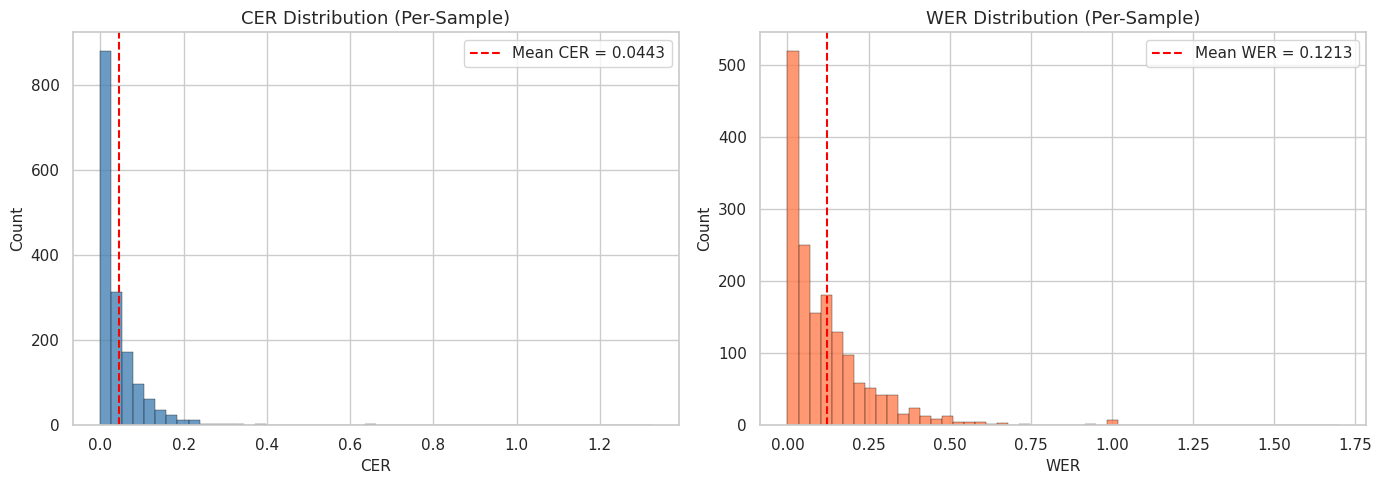

In [20]:
# --------------------------------------------------
# 3. Overall CER & WER
# --------------------------------------------------

# Tính per-sample CER and WER
df["cer"] = df.apply(
    lambda row: compute_cer(row["prediction"], row["ground_truth"]), axis=1
)
df["wer"] = df.apply(
    lambda row: compute_wer(row["prediction"], row["ground_truth"]), axis=1
)

# Macro averages
macro_cer = df["cer"].mean()
macro_wer = df["wer"].mean()

# Full-sequence accuracy: percentage of mẫu with CER = 0
exact_match_count = (df["cer"] == 0.0).sum()
full_seq_accuracy = exact_match_count / len(df) * 100

# Hiển thị results
overall_metrics = pd.DataFrame({
    "Metric": ["Macro CER", "Macro WER", "Full-Sequence Accuracy (%)", "Exact Matches", "Total Samples"],
    "Value": [
        f"{macro_cer:.4f}",
        f"{macro_wer:.4f}",
        f"{full_seq_accuracy:.2f}%",
        f"{exact_match_count:,}",
        f"{len(df):,}",
    ],
})

print("=" * 50)
print("METRICS ĐÁNH GIÁ TỔNG THỂ")
print("=" * 50)
display(overall_metrics)

# CER phân phối histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["cer"], bins=50, color="steelblue", edgecolor="black", linewidth=0.3, alpha=0.8)
axes[0].axvline(macro_cer, color="red", linestyle="--", linewidth=1.5, label=f"Mean CER = {macro_cer:.4f}")
axes[0].set_title("CER Distribution (Per-Sample)")
axes[0].set_xlabel("CER")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(df["wer"], bins=50, color="coral", edgecolor="black", linewidth=0.3, alpha=0.8)
axes[1].axvline(macro_wer, color="red", linestyle="--", linewidth=1.5, label=f"Mean WER = {macro_wer:.4f}")
axes[1].set_title("WER Distribution (Per-Sample)")
axes[1].set_xlabel("WER")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Phân tích theo nguồn


PHÂN TÍCH THEO NGUỒN


,Source,N Samples,Mean CER,Mean WER,Accuracy (%)
0,UIT_HWDB_line_flat,723,0.039349,0.105648,34.854772
1,VNOnDB_line,730,0.051327,0.136252,28.356164
2,vn_handwritten_images,184,0.035826,0.123419,32.608696


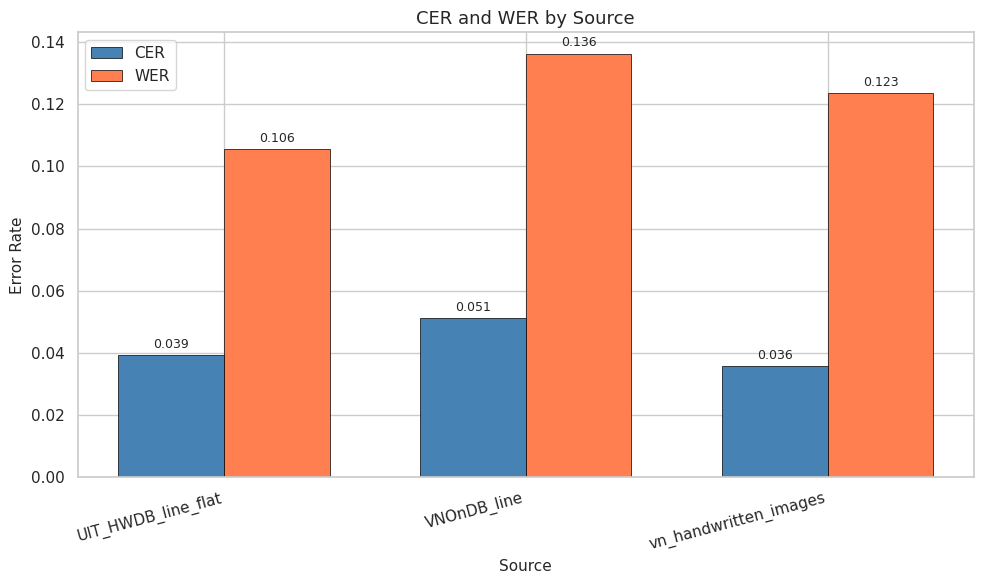

In [21]:
# --------------------------------------------------
# 4. Per-Source Breakdown
# --------------------------------------------------

source_groups = df.groupby("source")

source_metrics = []
for source_name, group in source_groups:
    n_samples = len(group)
    mean_cer = group["cer"].mean()
    mean_wer = group["wer"].mean()
    accuracy = (group["cer"] == 0.0).sum() / n_samples * 100

    source_metrics.append({
        "Source": source_name,
        "N Samples": n_samples,
        "Mean CER": mean_cer,
        "Mean WER": mean_wer,
        "Accuracy (%)": accuracy,
    })

df_source = pd.DataFrame(source_metrics)

print("=" * 60)
print("PHÂN TÍCH THEO NGUỒN")
print("=" * 60)
display(df_source)

# Grouped bar chart (CER and WER by source)
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_source))
width = 0.35

bars1 = ax.bar(x - width / 2, df_source["Mean CER"], width,
               label="CER", color="steelblue", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width / 2, df_source["Mean WER"], width,
               label="WER", color="coral", edgecolor="black", linewidth=0.5)

ax.set_xlabel("Source")
ax.set_ylabel("Error Rate")
ax.set_title("CER and WER by Source")
ax.set_xticks(x)
ax.set_xticklabels(df_source["Source"], rotation=15, ha="right")
ax.legend()

# Add value nhãn on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Phân tích theo bucket độ dài


PHÂN TÍCH THEO BUCKET ĐỘ DÀI


,Bucket,N Samples,Mean GT Length,Mean CER,Mean WER,Accuracy (%)
0,short (0-30),108,16.8,0.045701,0.138911,70.370370
1,medium (30-80),1235,64.8,0.040971,0.113410,31.821862
2,long (80-999),294,85.8,0.057740,0.147936,17.006803


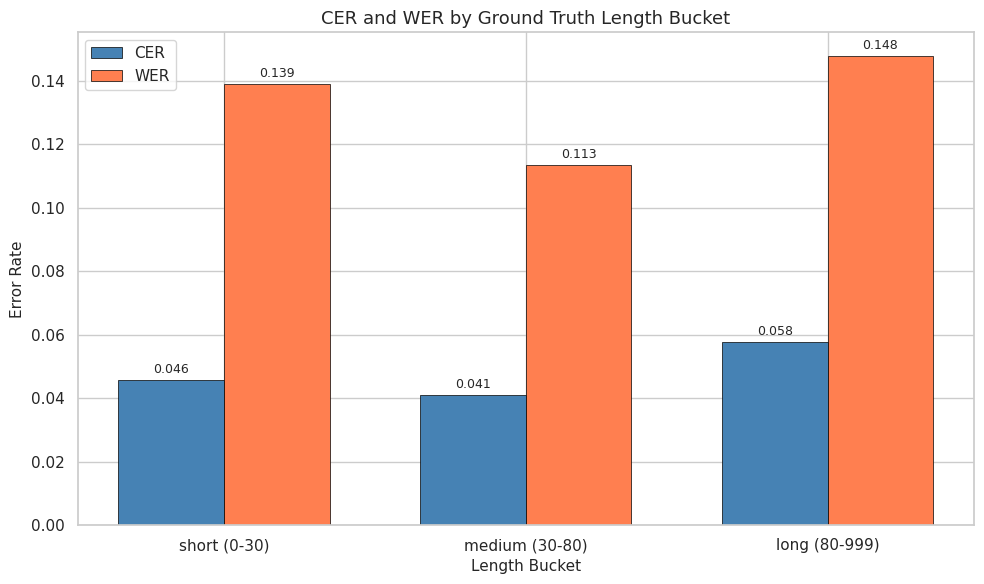

In [22]:
# --------------------------------------------------
# 5. Per-độ dài-Bucket Analysis
# --------------------------------------------------

# Tính ground truth độ dài
df["gt_length"] = df["ground_truth"].str.len()

# Assign buckets
def assign_bucket(length: int) -> str:
    """Assign a length bucket based on CONFIG thresholds."""
    for bucket_name, (lo, hi) in CONFIG["length_buckets"].items():
        if lo <= length < hi:
            return bucket_name
    return "unknown"


df["length_bucket"] = df["gt_length"].apply(assign_bucket)

# Tính metrics per bucket
bucket_order = ["short", "medium", "long"]
bucket_metrics = []

for bucket in bucket_order:
    group = df[df["length_bucket"] == bucket]
    if len(group) == 0:
        continue
    lo, hi = CONFIG["length_buckets"][bucket]
    bucket_metrics.append({
        "Bucket": f"{bucket} ({lo}-{hi})",
        "N Samples": len(group),
        "Mean GT Length": f"{group['gt_length'].mean():.1f}",
        "Mean CER": group["cer"].mean(),
        "Mean WER": group["wer"].mean(),
        "Accuracy (%)": (group["cer"] == 0.0).sum() / len(group) * 100,
    })

df_buckets = pd.DataFrame(bucket_metrics)

print("=" * 60)
print("PHÂN TÍCH THEO BUCKET ĐỘ DÀI")
print("=" * 60)
display(df_buckets)

# Biểu đồ cột
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_buckets))
width = 0.35

bars1 = ax.bar(x - width / 2, df_buckets["Mean CER"], width,
               label="CER", color="steelblue", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width / 2, df_buckets["Mean WER"], width,
               label="WER", color="coral", edgecolor="black", linewidth=0.5)

ax.set_xlabel("Length Bucket")
ax.set_ylabel("Error Rate")
ax.set_title("CER and WER by Ground Truth Length Bucket")
ax.set_xticks(x)
ax.set_xticklabels(df_buckets["Bucket"])
ax.legend()

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 6. Ma trận nhầm lẫn ký tự (Top-20)


Đang tính character alignments...


Aligning:   0%|          | 0/1637 [00:00<?, ?it/s]


TOP-20 CÁC CẶP NHẦM KÝ TỰ


,GT Char,Pred Char,Count
Rank,,,
1,m,n,64
2,u,n,45
3,n,m,32
4,T,t,25
5,.,",",25
6,t,đ,25
7,C,c,22
8,n,u,21
9,t,c,21


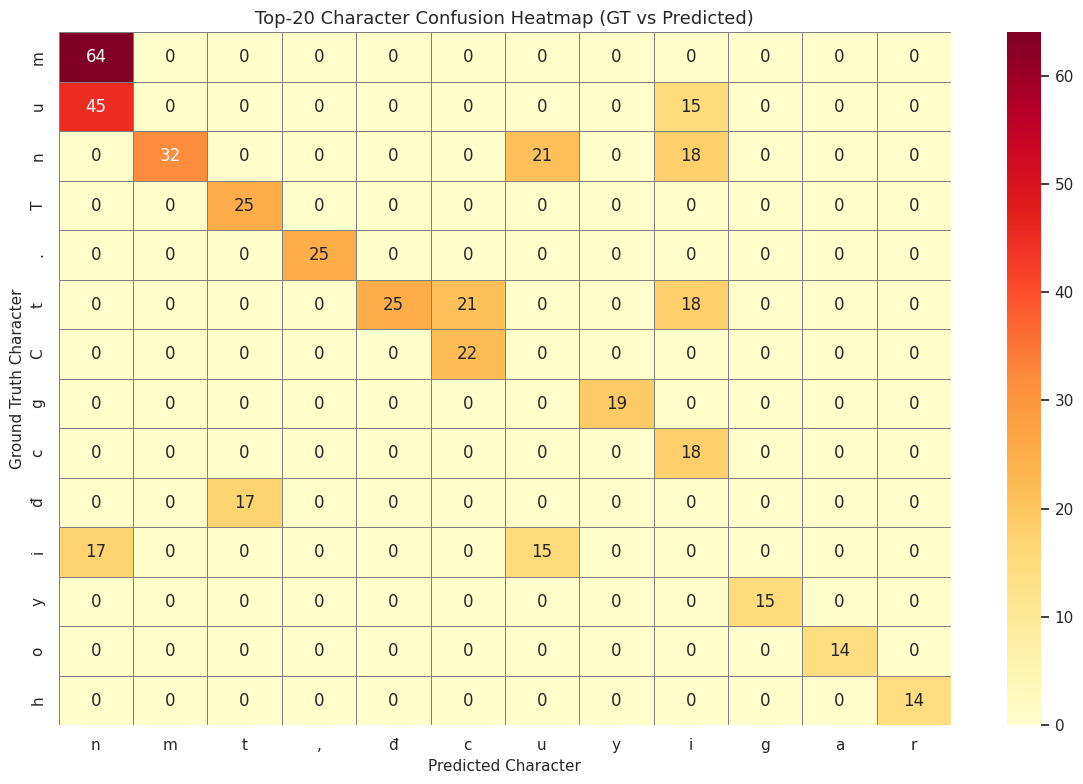

In [23]:
# --------------------------------------------------
# 6. Character Confusion Matrix (Top-20)
# --------------------------------------------------

# Run căn chỉnh ký tự on all mẫu
print("Đang tính character alignments...")
all_alignments = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Aligning"):
    alignment = character_alignment(row["prediction"], row["ground_truth"])
    all_alignments.append(alignment)

# Xây dựng confusion pairs
confusion_pairs = build_confusion_pairs(all_alignments)

# Hiển thị top-20 as DataFrame
top_n_confusion = 20
df_confusion = pd.DataFrame(
    confusion_pairs[:top_n_confusion],
    columns=["GT Char", "Pred Char", "Count"],
)
df_confusion.index = range(1, len(df_confusion) + 1)
df_confusion.index.name = "Rank"

print(f"\n{'='*50}")
print(f"TOP-{top_n_confusion} CÁC CẶP NHẦM KÝ TỰ")
print(f"{'='*50}")
display(df_confusion)

# Heatmap of top confusion pairs
# Xây dựng a pivot-style matrix from the top pairs
top_pairs = confusion_pairs[:top_n_confusion]

# Get độc nhất GT and Pred chars from top pairs
gt_chars_in_top = list(dict.fromkeys([p[0] for p in top_pairs]))
pred_chars_in_top = list(dict.fromkeys([p[1] for p in top_pairs]))

# Xây dựng matrix
heatmap_data = pd.DataFrame(
    0, index=gt_chars_in_top, columns=pred_chars_in_top, dtype=int
)
for gt_c, pred_c, count in top_pairs:
    if gt_c in heatmap_data.index and pred_c in heatmap_data.columns:
        heatmap_data.loc[gt_c, pred_c] = count

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="gray",
    ax=ax,
)
ax.set_title(f"Top-{top_n_confusion} Character Confusion Heatmap (GT vs Predicted)")
ax.set_xlabel("Predicted Character")
ax.set_ylabel("Ground Truth Character")
plt.tight_layout()
plt.show()

## 7. Tỷ lệ lỗi theo dấu tiếng Việt


PHÂN TÍCH LỖI THEO DIACRITIC


,Category,Total Chars,Errors,Error Rate
0,Diacritic Characters,23060,1645,0.0713 (7.13%)
1,Base Characters,83959,2627,0.0313 (3.13%)
2,All Characters,107019,4272,0.0399 (3.99%)


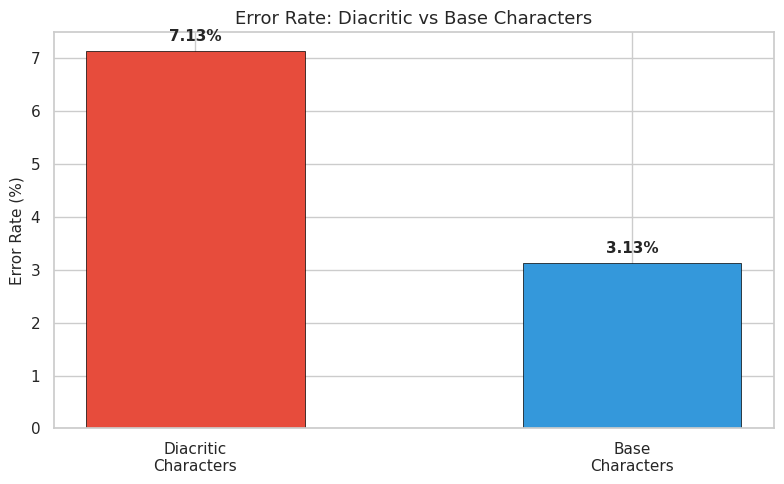

In [24]:
    # --------------------------------------------------
    # 7. Diacritic-Specific Error Rate
    # --------------------------------------------------

    # Define Vietnamese diacritic ký tự using unicodedata
    # A character is considered "diacritic" if:
    #   - It is a letter AND its NFC-decomposed form has more than one codepoint
    #     (i.e., it has combining marks), OR
    #   - It is in the explicit Vietnamese diacritic set.

    VIETNAMESE_DIACRITIC_CHARS = set(
        # Base vowels with diacritics
        "ăâđêôơư"
        "ĂÂĐÊÔƠƯ"
        # Tonal variants
        "àáảãạ" "ằắẳẵặ" "ầấẩẫậ"
        "èéẻẽẹ" "ềếểễệ"
        "ìíỉĩị"
        "òóỏõọ" "ồốổỗộ" "ờớởỡợ"
        "ùúủũụ" "ừứửữự"
        "ỳýỷỹỵ"
        # Uppercase tonal variants
        "ÀÁẢÃẠ" "ẰẮẲẴẶ" "ẦẤẨẪẬ"
        "ÈÉẺẼẸ" "ỀẾỂỄỆ"
        "ÌÍỈĨỊ"
        "ÒÓỎÕỌ" "ỒỐỔỖỘ" "ỜỚỞỠỢ"
        "ÙÚỦŨỤ" "ỪỨỬỮỰ"
        "ỲÝỶỸỴ"
    )


    def is_diacritic_char(ch: str) -> bool:
        """Check if a character is a Vietnamese diacritic character.

        Uses both the explicit set and unicodedata decomposition check.

        Args:
            ch: Single character string.

        Returns:
            True if the character has diacritics.
        """
        if ch in VIETNAMESE_DIACRITIC_CHARS:
            return True
        # Kiểm tra via unicodedata: if NFD decomposition yields more than 1 codepoint,
        # the character has combining marks
        if ch.isalpha():
            nfd = unicodedata.normalize("NFD", ch)
            if len(nfd) > 1:
                return True
        return False


    # Tính diacritic vs base char errors per sample
    diacritic_total = 0
    diacritic_errors = 0
    base_total = 0
    base_errors = 0

    for _, row in df.iterrows():
        gt = row["ground_truth"]
        pred = row["prediction"]

        # Use căn chỉnh ký tự to get full alignment (not just substitutions)
        n_gt = len(gt)
        m_pred = len(pred)

        # Full DP alignment with backtracking for all operations
        dp = [[0] * (m_pred + 1) for _ in range(n_gt + 1)]
        for i in range(n_gt + 1):
            dp[i][0] = i
        for j in range(m_pred + 1):
            dp[0][j] = j

        for i in range(1, n_gt + 1):
            for j in range(1, m_pred + 1):
                if gt[i - 1] == pred[j - 1]:
                    dp[i][j] = dp[i - 1][j - 1]
                else:
                    dp[i][j] = 1 + min(
                        dp[i - 1][j],
                        dp[i][j - 1],
                        dp[i - 1][j - 1],
                    )

        # Backtrack
        i, j = n_gt, m_pred
        while i > 0 or j > 0:
            if i > 0 and j > 0 and gt[i - 1] == pred[j - 1]:
                # Match -- correct
                ch = gt[i - 1]
                if is_diacritic_char(ch):
                    diacritic_total += 1
                else:
                    base_total += 1
                i -= 1
                j -= 1
            elif i > 0 and j > 0 and dp[i][j] == dp[i - 1][j - 1] + 1:
                # Substitution -- error
                ch = gt[i - 1]
                if is_diacritic_char(ch):
                    diacritic_total += 1
                    diacritic_errors += 1
                else:
                    base_total += 1
                    base_errors += 1
                i -= 1
                j -= 1
            elif i > 0 and dp[i][j] == dp[i - 1][j] + 1:
                # Deletion -- gt char has no match
                ch = gt[i - 1]
                if is_diacritic_char(ch):
                    diacritic_total += 1
                    diacritic_errors += 1
                else:
                    base_total += 1
                    base_errors += 1
                i -= 1
            elif j > 0:
                # Insertion -- extra predicted char (counts as error but not
                # attributed to a specific gt char class)
                j -= 1
            else:
                break

    # Tính tỷ lệ lỗi
    diacritic_error_rate = diacritic_errors / diacritic_total if diacritic_total > 0 else 0.0
    base_error_rate = base_errors / base_total if base_total > 0 else 0.0

    print("=" * 60)
    print("PHÂN TÍCH LỖI THEO DIACRITIC")
    print("=" * 60)

    df_diacritic = pd.DataFrame({
        "Category": ["Diacritic Characters", "Base Characters", "All Characters"],
        "Total Chars": [diacritic_total, base_total, diacritic_total + base_total],
        "Errors": [diacritic_errors, base_errors, diacritic_errors + base_errors],
        "Error Rate": [
            f"{diacritic_error_rate:.4f} ({diacritic_error_rate * 100:.2f}%)",
            f"{base_error_rate:.4f} ({base_error_rate * 100:.2f}%)",
            f"{(diacritic_errors + base_errors) / (diacritic_total + base_total):.4f} "
            f"({(diacritic_errors + base_errors) / (diacritic_total + base_total) * 100:.2f}%)"
            if (diacritic_total + base_total) > 0 else "N/A",
        ],
    })

    display(df_diacritic)

    # Biểu đồ cột comparison
    fig, ax = plt.subplots(figsize=(8, 5))
    categories = ["Diacritic\nCharacters", "Base\nCharacters"]
    error_rates = [diacritic_error_rate * 100, base_error_rate * 100]
    colors = ["#e74c3c", "#3498db"]

    bars = ax.bar(categories, error_rates, color=colors, edgecolor="black", linewidth=0.5, width=0.5)
    ax.set_title("Error Rate: Diacritic vs Base Characters")
    ax.set_ylabel("Error Rate (%)")

    for bar, rate in zip(bars, error_rates):
        ax.annotate(f"{rate:.2f}%",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 5), textcoords="offset points",
                    ha="center", va="bottom", fontsize=11, fontweight="bold")

    plt.tight_layout()
    plt.show()

## 8. 20 dự đoán tệ nhất


TOP 20 CÁC DỰ ĐOÁN TỆ NHẤT (by CER)


,image_path,ground_truth,prediction,source,cer,wer
Rank,,,,,,
1,VNOnDB_line__20160512_0129_9244_1_tg_3_5.png,chị bỗng ĐDV trực ban cho biết có ca cấp cứu đ...,đi thông thương tư tư trì chỉ trì một cả hàng ...,VNOnDB_line,1.324324,1.647059
2,VNOnDB_line__20151109_0045_25288_tg_0_0.png,"một lãnh đạo thanh tra Bộ Y tế cho biết : "" Ch...","trường tiền số của cơ ng tiến cư xé "" chị cứ t...",VNOnDB_line,1.234568,1.700000
3,UIT_HWDB_line_flat__91_1.jpg,"một lãnh đạo thanh tra Bộ Y tế cho biết : "" Ch...","trước của Là của có tà từ tro có bó "" công cư ...",UIT_HWDB_line_flat,1.209877,1.400000
4,UIT_HWDB_line_flat__12_6.jpg,"Họ lặn cả ngày, có khi cả đêm, dưới biển lạnh ...","như trường "" tiên lên nà cơ không tư chư chưa ...",UIT_HWDB_line_flat,1.100000,1.428571
5,UIT_HWDB_line_flat__106_31.jpg,"trại số 4 đi, vùi lấp anh em.","trường trình đã trì của bệ cho "".",UIT_HWDB_line_flat,0.827586,1.000000
6,VNOnDB_line__20160510_0119_26558_1_tg_1_6.png,cho tổng công ty để đẩy nhanh hơn tốc độ cổ ph...,thông tông tông ty thì ký tước tra trì tự trìn...,VNOnDB_line,0.660377,0.923077
7,UIT_HWDB_line_flat__207_12.jpg,cho tổng công ty để đẩy nhanh hơn tốc độ cổ ph...,"thông công ty từ thì tân hà từ tình tình... "" ...",UIT_HWDB_line_flat,0.641509,0.923077
8,VNOnDB_line__20160412_0091_9539_1_tg_2_0.png,Ba Phước đang là chủ tịch hội đồng quản trị do...,cao phúc trong là chương tại thì trì giư tự li...,VNOnDB_line,0.525641,0.823529
9,UIT_HWDB_line_flat__51_27.jpg,dày đặc.,dòng đoặc.,UIT_HWDB_line_flat,0.500000,1.000000


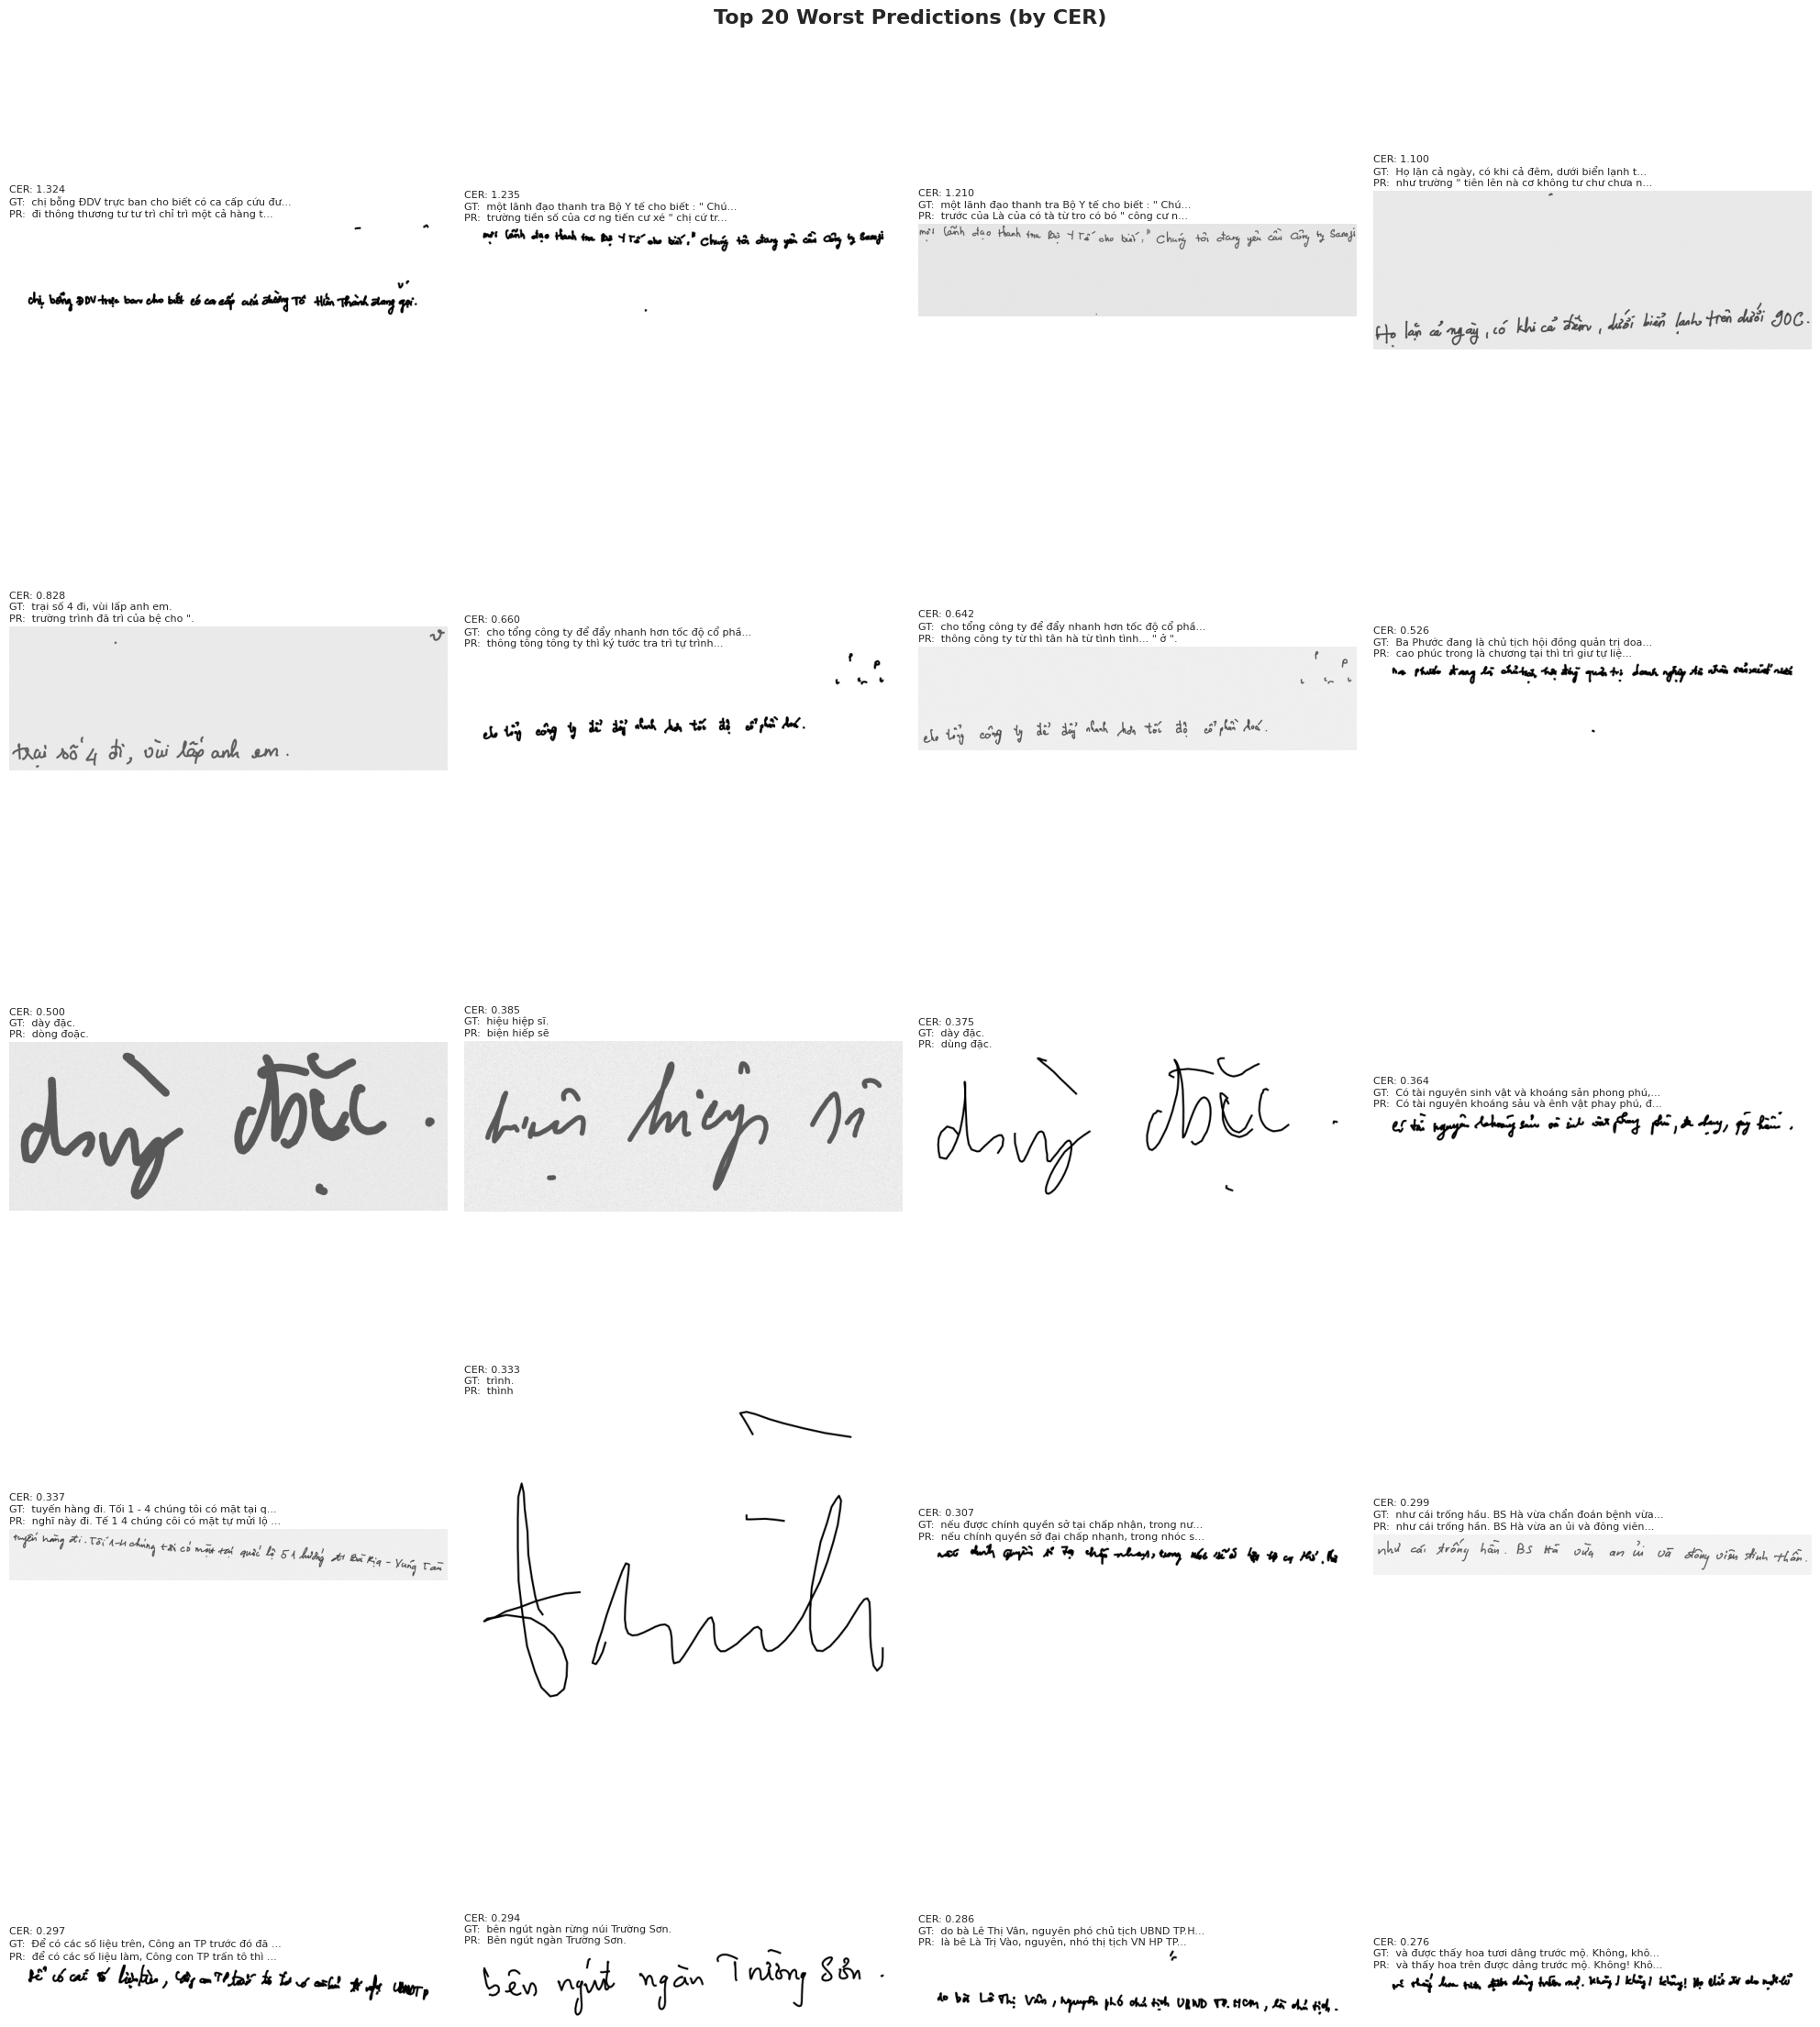

In [25]:
# --------------------------------------------------
# 8. Tệ nhất 20 Predictions
# --------------------------------------------------

n_worst = CONFIG["num_worst"]

# Get worst dự đoán
df_worst = df.nlargest(n_worst, "cer")[
    ["image_path", "ground_truth", "prediction", "source", "cer", "wer"]
].reset_index(drop=True)
df_worst.index = range(1, len(df_worst) + 1)
df_worst.index.name = "Rank"

print(f"{'='*60}")
print(f"TOP {n_worst} CÁC DỰ ĐOÁN TỆ NHẤT (by CER)")
print(f"{'='*60}")
display(df_worst)

# trực quan hóa
visualize_worst(df, n=n_worst)

## 9. Lưu kết quả đánh giá


In [26]:
# --------------------------------------------------
# 9. Lưu Evaluation Results
# --------------------------------------------------

os.makedirs(CONFIG["output_dir"], exist_ok=True)
split_tag = CONFIG["eval_split"]

# --- 9a. Lưu full results DataFrame to CSV ---
csv_path = os.path.join(CONFIG["output_dir"], f"evaluation_results_{split_tag}.csv")
df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"Đã lưu full results tại: {csv_path}")
print(f"  Shape: {df.shape}")

# --- 9b. Prepare tóm tắt metrics ---
summary = {
    "overall": {
        "eval_split": split_tag,
        "n_eval_samples": len(df),
        "n_prediction_errors": len(errors),
        "macro_cer": float(macro_cer),
        "macro_wer": float(macro_wer),
        "full_sequence_accuracy_pct": float(full_seq_accuracy),
        "exact_matches": int(exact_match_count),
    },
    "per_source": {
        row["Source"]: {
            "n_samples": int(row["N Samples"]),
            "mean_cer": float(row["Mean CER"]),
            "mean_wer": float(row["Mean WER"]),
            "accuracy_pct": float(row["Accuracy (%)"]),
        }
        for _, row in df_source.iterrows()
    },
    "per_length_bucket": {
        row["Bucket"]: {
            "n_samples": int(row["N Samples"]),
            "mean_gt_length": float(row["Mean GT Length"]),
            "mean_cer": float(row["Mean CER"]),
            "mean_wer": float(row["Mean WER"]),
            "accuracy_pct": float(row["Accuracy (%)"]),
        }
        for _, row in df_buckets.iterrows()
    },
    "diacritic_analysis": {
        "diacritic_total_chars": int(diacritic_total),
        "diacritic_errors": int(diacritic_errors),
        "diacritic_error_rate": float(diacritic_error_rate),
        "base_total_chars": int(base_total),
        "base_errors": int(base_errors),
        "base_error_rate": float(base_error_rate),
    },
    "top_20_confusion_pairs": [
        {"gt_char": gt_c, "pred_char": pred_c, "count": int(cnt)}
        for gt_c, pred_c, cnt in confusion_pairs[:20]
    ],
    "config": {
        "model_path": CONFIG["model_path"],
        "backbone": CONFIG["backbone"],
        "device": CONFIG["device"],
        "eval_split": CONFIG["eval_split"],
        "length_buckets": {k: list(v) for k, v in CONFIG["length_buckets"].items()},
    },
}

# --- 9c. Lưu tóm tắt JSON ---
json_path = os.path.join(CONFIG["output_dir"], f"evaluation_summary_{split_tag}.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"Đã lưu summary metrics tại: {json_path}")

print(f"\nCác file đã lưu:")
print(f"  1. {os.path.abspath(csv_path)}")
print(f"  2. {os.path.abspath(json_path)}")

Đã lưu full results tại: ../models/baseline/evaluation_results_test.csv
  Shape: (1637, 8)
Đã lưu summary metrics tại: ../models/baseline/evaluation_summary_test.json

Các file đã lưu:
  1. /mnt/c/Users/Acer Nitro/Documents/Projects/OCR_project/ocr_ai_agent_coding/models/baseline/evaluation_results_test.csv
  2. /mnt/c/Users/Acer Nitro/Documents/Projects/OCR_project/ocr_ai_agent_coding/models/baseline/evaluation_summary_test.json


## 10. Tổng kết


## Mô tả từng cell (Notebook 04) và tổng kết

### Mô tả từng cell
- **Cell 1 (Markdown):** Giới thiệu mục tiêu đánh giá Baseline model.
- **Cell 2 (Code):** Khai báo cấu hình đánh giá (đường dẫn model/data, tham số evaluate).
- **Cell 3 (Markdown):** Ghi chú refactor về vocabulary do VietOCR quản lý.
- **Cell 4 (Code):** Import thư viện.
- **Cell 5 (Code):** Định nghĩa helper functions cho metric/phân tích lỗi.
- **Cell 6 (Markdown):** Mục 1 — Tải model và dữ liệu validation.
- **Cell 7 (Code):** Tạo predictor, nạp weights, đọc validation annotations.
- **Cell 8 (Markdown):** Mục 2 — Chạy dự đoán trên toàn bộ validation set.
- **Cell 9 (Code):** Infer toàn bộ validation và lưu kết quả vào DataFrame.
- **Cell 10 (Markdown):** Mục 3 — CER & WER tổng thể.
- **Cell 11 (Code):** Tính metric tổng, độ chính xác chuỗi đầy đủ và trực quan phân bố lỗi.
- **Cell 12 (Markdown):** Mục 4 — Phân tích theo source.
- **Cell 13 (Code):** Tính CER/WER theo từng nguồn dữ liệu.
- **Cell 14 (Markdown):** Mục 5 — Phân tích theo bucket độ dài.
- **Cell 15 (Code):** Chia bucket theo độ dài nhãn và tính metric.
- **Cell 16 (Markdown):** Mục 6 — Ma trận nhầm lẫn ký tự (Top-20).
- **Cell 17 (Code):** Trích cặp nhầm lẫn ký tự phổ biến và vẽ heatmap.
- **Cell 18 (Markdown):** Mục 7 — Tỷ lệ lỗi theo diacritic.
- **Cell 19 (Code):** So sánh lỗi ký tự có dấu và ký tự cơ bản.
- **Cell 20 (Markdown):** Mục 8 — 20 dự đoán tệ nhất.
- **Cell 21 (Code):** Trích và hiển thị các mẫu có CER cao nhất.
- **Cell 22 (Markdown):** Mục 9 — Lưu kết quả đánh giá.
- **Cell 23 (Code):** Xuất kết quả chi tiết CSV và summary JSON.
- **Cell 24 (Markdown):** Mục 10 — Tổng kết.

### Tổng kết file 04
Notebook 04 là bước đánh giá toàn diện Baseline: đo metric tổng thể, phân tích theo source/độ dài/diacritic, soi lỗi điển hình và xuất báo cáo phục vụ cải tiến mô hình ở giai đoạn tiếp theo.